# Customer Segmentation using K-Means Clustering

## Objective

The objective of this project is to segment mall customers into different groups based on their purchasing behaviour using K-Means Clustering.

The business can use these customer segments to:

- Identify VIP customers
- Improve marketing strategies
- Increase customer retention
- Provide personalized recommendations

## Dataset

Dataset Name:
Mall Customers Dataset

Features:

- CustomerID
- Gender (Genre)
- Age
- Annual Income (k$)
- Spending Score (1-100)

Target:
There is no target column because this is an Unsupervised Machine Learning problem.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

## Load Dataset

The dataset is loaded into a pandas DataFrame.

In [3]:
data=pd.read_csv(r"C:\Users\anujb\Downloads\archive mall\Mall_Customers.csv")

In [4]:
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
data.shape

(200, 5)

In [6]:
data.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

## Understanding the Dataset

Before building the model, we first inspect the dataset to understand:

- Number of rows
- Number of columns
- Data types
- Missing values

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [8]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
data.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [10]:
data.duplicated().sum()

np.int64(0)

# Data Visualization

## Objective

Data visualization helps us understand the distribution of customer features, identify patterns, detect outliers, and observe relationships between variables before applying clustering algorithms.

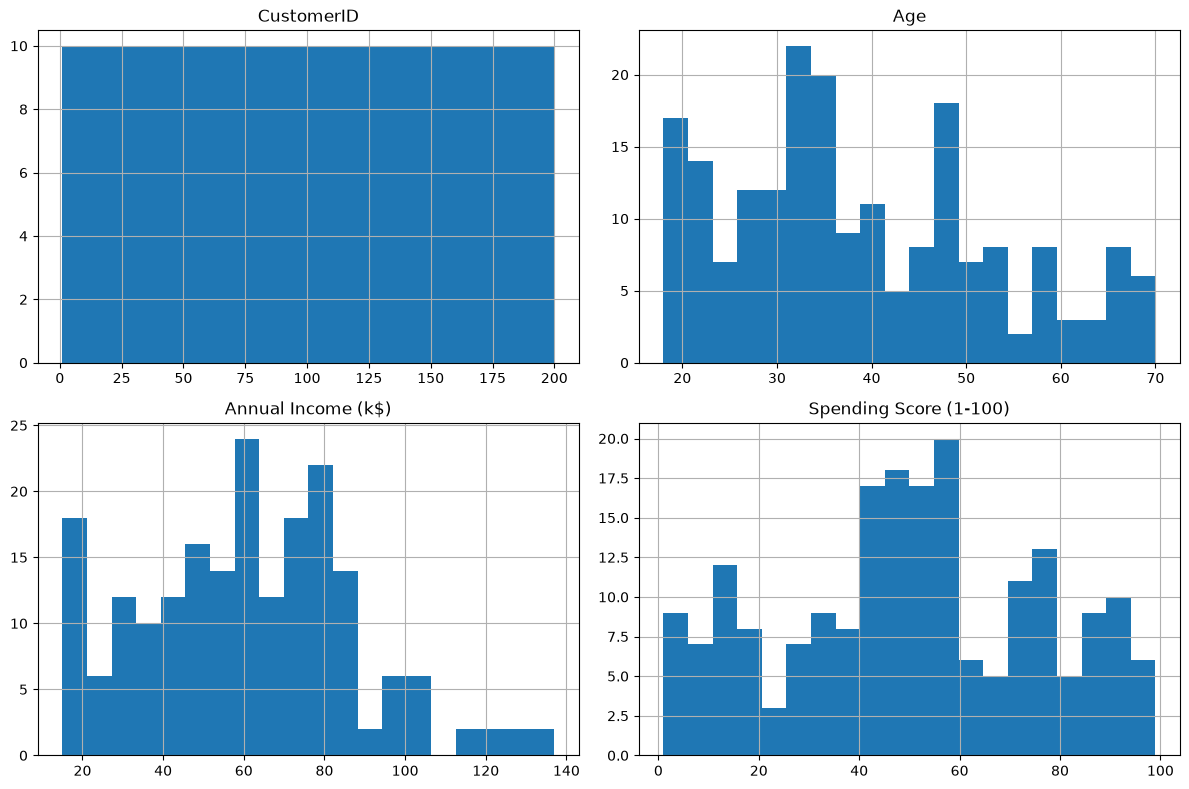

In [11]:
#distrubtion of numeric features:-

data.hist(figsize=(12,8),bins=20)
plt.tight_layout()
plt.show()

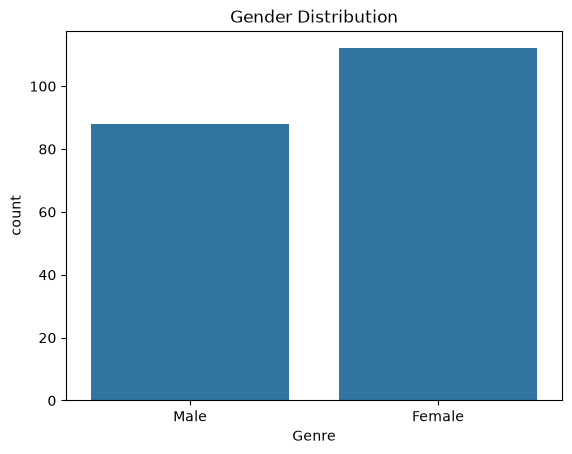

In [12]:
#Gender Distribution (using count plot):-

sns.countplot(x="Genre",data=data)
plt.title("Gender Distribution")
plt.show()

### Interpretation

- This graph shows the number of male and female customers.
- The dataset is nearly balanced between genders.
- Therefore, clustering will not be heavily biased toward one gender.

## Age Distribution

The histogram below shows the distribution of customer ages.

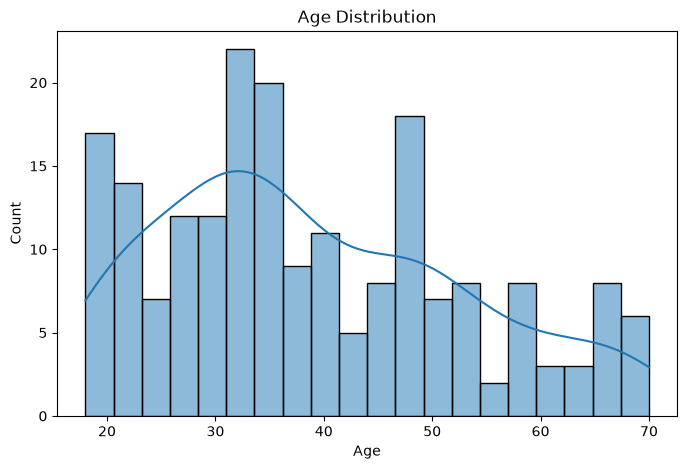

In [13]:
#Checking Which age group visited mall mostly:-

plt.figure(figsize=(8,5))
sns.histplot(data["Age"],bins=20,kde=True)
plt.title("Age Distribution")
plt.show()

### Interpretation

- Most customers belong to the age group of approximately 20–40 years.
- There are fewer older customers above 60 years.
- The distribution is slightly right-skewed because fewer elderly customers are present.

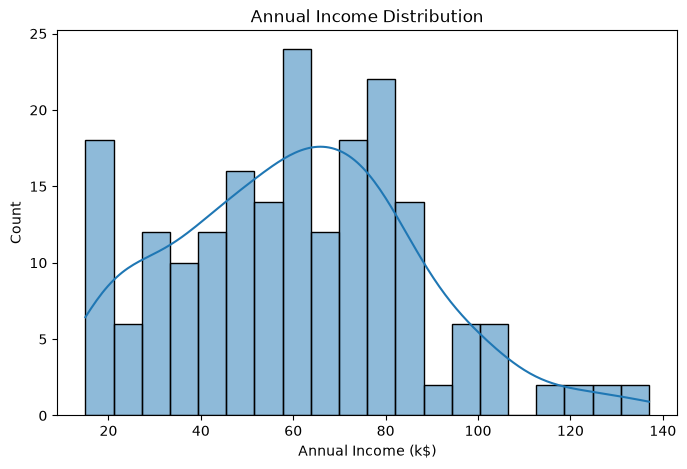

In [14]:
#Checking High Income,Low Income,Evenly Distributed Income:-

plt.figure(figsize=(8,5))
sns.histplot(data["Annual Income (k$)"], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.show()

### Interpretation

- Customer income ranges from low to high.
- Most customers fall within the middle-income category.
- The dataset contains customers from different income groups, making it suitable for segmentation.

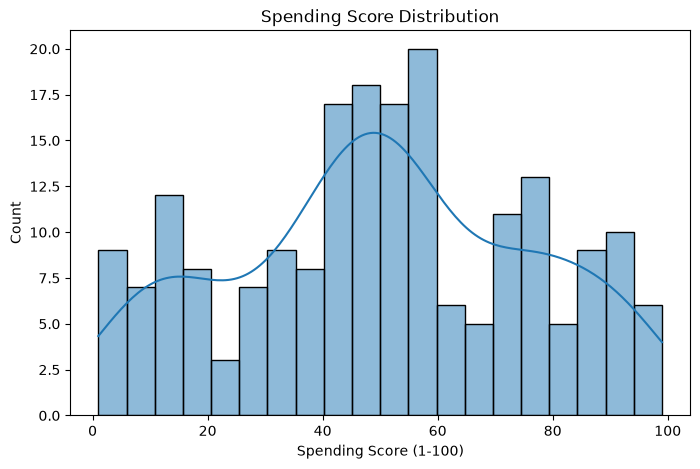

In [15]:
#Checking High Spender,Average Spender,Low Spender:-

plt.figure(figsize=(8,5))
sns.histplot(data["Spending Score (1-100)"], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()

### Interpretation

- Spending scores are spread across the entire range.
- Both low and high spenders are present.
- This variation makes spending score an important feature for customer segmentation.

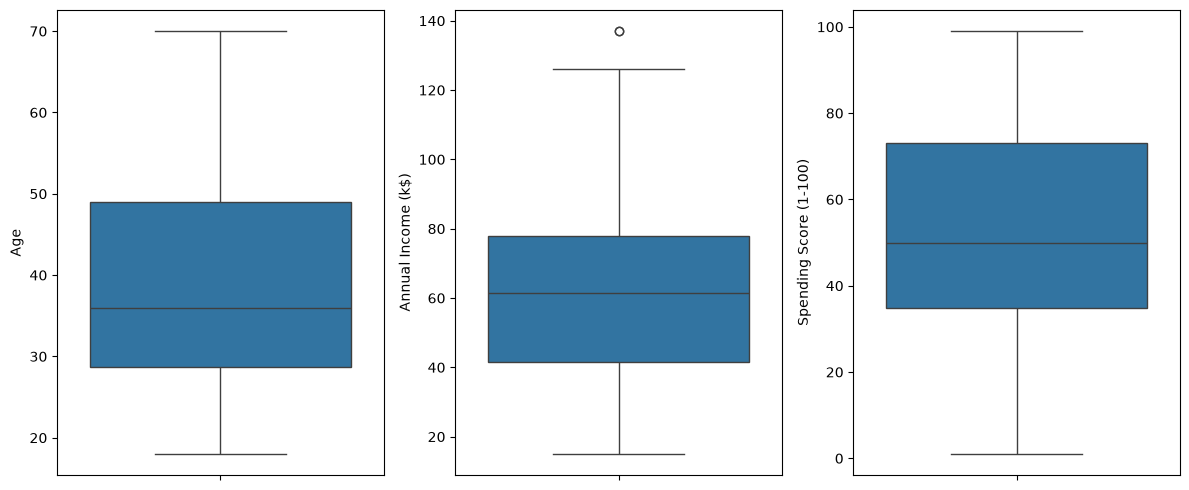

In [16]:
#Checking Outliers,median,spread of data:-

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
sns.boxplot(y=data["Age"])

plt.subplot(1,3,2)
sns.boxplot(y=data["Annual Income (k$)"])

plt.subplot(1,3,3)
sns.boxplot(y=data["Spending Score (1-100)"])

plt.tight_layout()
plt.show()

## Age:
### Interpretation:-
- The median customer age is approximately 36 years.
- Most customers belong to the age group of 29–49 years.
- No significant outliers are present in the Age feature.
- Therefore, the Age data is well distributed and does not require outlier treatment.


## Annual Income (k$):
### Interpretation:-
- Most customers have annual incomes between 41k and 77k dollars.
- The median annual income is approximately 61k dollars.
- One high-income outlier is observed.
- Since this value may represent a genuine premium customer rather than a data entry error, it is retained for clustering.

## Spending Score (1-100):
### Interpretation:-
- The median spending score is approximately 50.
- Spending behavior varies widely among customers.
- No significant outliers are present.
- The Spending Score feature provides strong variability, making it useful for customer segmentation.

## Overall Interpretation:
- Age and Spending Score do not contain significant outliers.
- Annual Income contains one high-income outlier.
- Since the outlier likely represents a genuine customer rather than an error, it is retained.
- Overall, the dataset is clean and suitable for K-Means clustering.

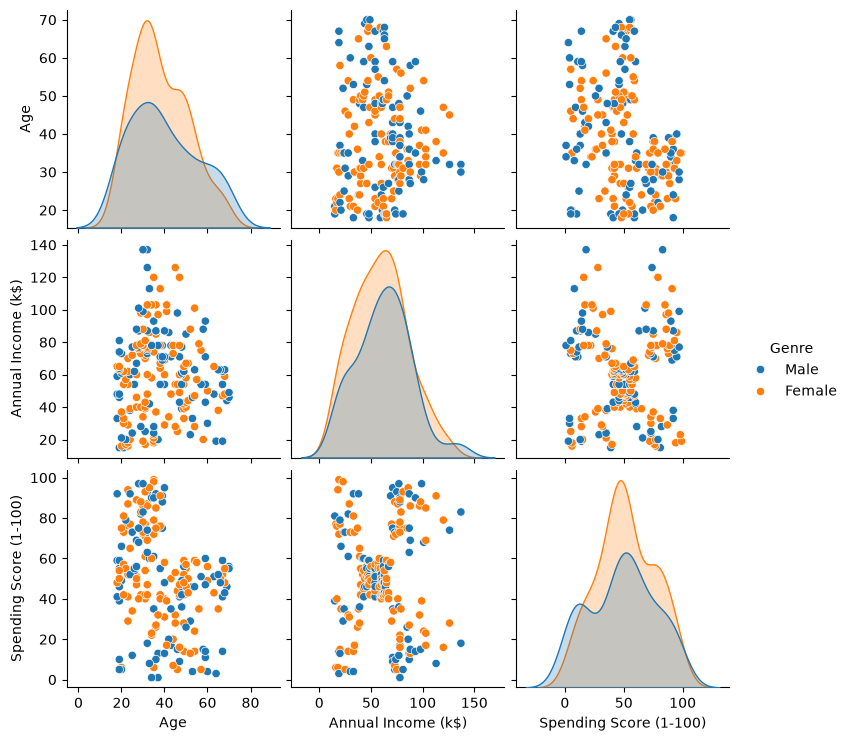

In [17]:
#Checking relationship between the features(Natural Cluster,Postive/Negative Relationship):-

sns.pairplot(
    data,
    hue="Genre",
    vars=["Age","Annual Income (k$)","Spending Score (1-100)"]
)
plt.show()

### Interpretation

The pairplot helps us understand relationships between numerical variables.

Observations:

- Spending Score and Annual Income show visible grouping.
- Age has a weaker relationship with Spending Score.
- Gender does not create a very clear separation.

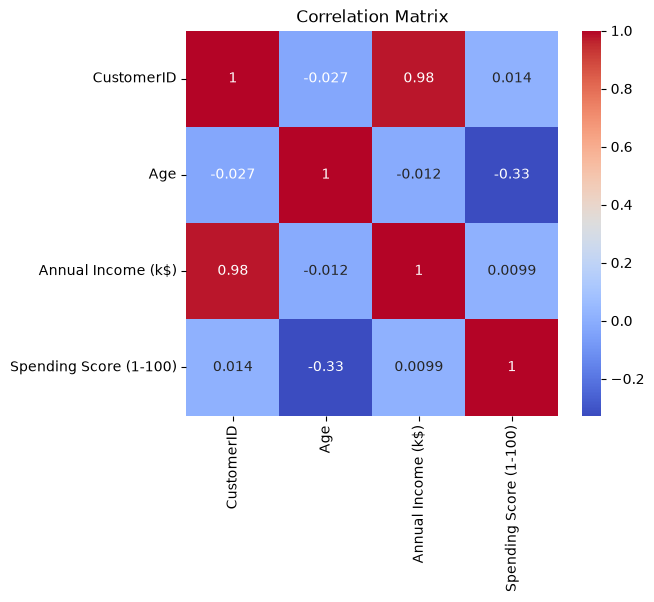

In [18]:
#Checking Correlation:-

plt.figure(figsize=(6,5))
corr=data.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

### Interpretation

- Annual Income and Spending Score show a weak positive correlation.
- Age has a slight negative correlation with Spending Score.
- No strong multicollinearity exists among the numerical features.
- Therefore, all numerical features can be retained for clustering.

In [19]:
#We Does'nt need customerId beacuse it does'nt giving any information (if we will not remove it will become the part of k-means and can effect the results):-

X=data.drop("CustomerID",axis=1)
X.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


### Interpretation

The `CustomerID` column was removed because it is only a unique identifier and does not provide any useful information for customer segmentation.

The remaining features are:

- Gender
- Age
- Annual Income (k$)
- Spending Score (1–100)

These features will be used to build the clustering model.

In [20]:
# encoding(Converting gender in 1,0 (Converting categorical data)):-

X["Genre"]=X["Genre"].map({
    "Male":1,
    "Female":0
})
X.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


### Interpretation

The Gender feature was converted from categorical values to numerical values using Label Encoding.

Encoding is necessary because K-Means clustering calculates Euclidean distance, which can only be computed on numerical data.

The encoded values do not represent ranking; they simply allow the algorithm to process categorical information.

In [21]:
#Standarizing the features (StandardScaler ensures all features have the same scale):-

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled=pd.DataFrame(
    X_scaled,
    columns=X.columns
)
X.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


### Interpretation

The numerical features were standardized using StandardScaler.

Standardization transformed all features to have:

- Mean = 0
- Standard Deviation = 1

This ensures that all features contribute equally to the Euclidean distance used by the K-Means clustering algorithm.

In [22]:
#PCA reduces the number of features while preserving as much important information as possible.(we are doing it so that we can analysis it since the dataset contain more than 2 features which is difficult for ploting the graph(x,y axis))

from sklearn.decomposition import PCA
pca=PCA(n_components=2)

X_pca=pca.fit_transform(X_scaled)

X_pca=pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"] #we can have more then two which will give us the rest of variance(information)
)

print(X_pca.head())
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

        PC1       PC2
0 -0.406383 -0.520714
1 -1.427673 -0.367310
2  0.050761 -1.894068
3 -1.694513 -1.631908
4 -0.313108 -1.810483
Explained Variance Ratio:
[0.33690046 0.26230645]


In [23]:
# [0.33690046 0.26230645]=  (PC1=33% , PC2=26%) information preseve
# (59%)Total That is fine for visualization, but if PCA were being used for model training, we might keep 3 or 4 components instead.

### Interpretation

Principal Component Analysis (PCA) reduced the original dataset into two principal components.

The first principal component (PC1) captures the maximum variance in the dataset, while the second principal component (PC2) captures the second highest variance.

These two components preserve a significant portion of the original information and make it possible to visualize customer clusters in two dimensions.

In [24]:
#Finding Best fit value for k(It will decide how many cluster will form)/(Using Elbow Method):-

wcss=[]
for k in range(1,11):
    kmeans=KMeans(
        n_clusters=k,
        random_state=42
    )
    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Finding the Optimal Number of Clusters using the Elbow Method

## Objective

K-Means requires the number of clusters (**K**) to be specified before training.

The Elbow Method helps determine the optimal value of K by calculating the Within-Cluster Sum of Squares (WCSS) for different values of K.

The best K is chosen where the decrease in WCSS starts slowing down, forming an "elbow" in the graph.

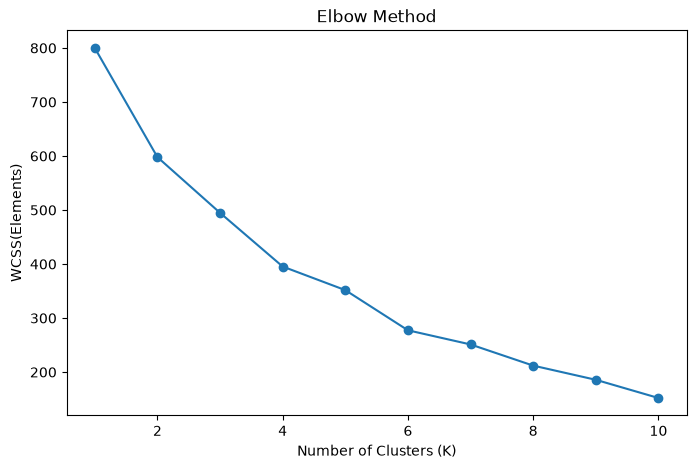

In [25]:
#Ploting graph for k (Elbow Method):-

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS(Elements)")
plt.title("Elbow Method")

plt.show()

In [26]:
# from graph we can see there is not much of difference but we can have k=5 or 6

### Interpretation

The Elbow Method was used to determine the optimal number of clusters.

As the number of clusters increased, the WCSS decreased because data points became closer to their respective centroids.

The curve showed a noticeable bend (elbow) at **K = 5**, indicating that five clusters provide a good balance between model simplicity and clustering performance.

Therefore, **K = 5,6** was selected for the K-Means model.

In [27]:
#Training the model

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 4)","[

# Model Training

## Objective

After determining the optimal number of clusters using the Elbow Method, the K-Means clustering algorithm is trained using **K = 5**.

The objective is to group customers into five distinct clusters based on their similarities.

In [28]:
#Labelling the clusters(means providing the clusters to each customers like belongs to cluster 1,2,3,4):-

clusters = kmeans.labels_

print(clusters[:10])

[2 2 4 4 4 4 4 4 0 4]


In [29]:
data["Cluster"] = clusters

data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,4
4,5,Female,31,17,40,4


### Interpretation

The K-Means clustering model was trained using **5 clusters**.

Each customer was assigned to the nearest cluster based on Euclidean distance.

A new column named **Cluster** was added to the dataset, indicating the cluster membership of each customer.

These cluster labels are later used to analyze customer segments and generate business insights.

In [30]:
#value counts for each clusters:-

print(data["Cluster"].value_counts())

Cluster
0    51
3    49
2    42
4    38
1    20
Name: count, dtype: int64


### Interpretation

Counting the value count of each Cluster.

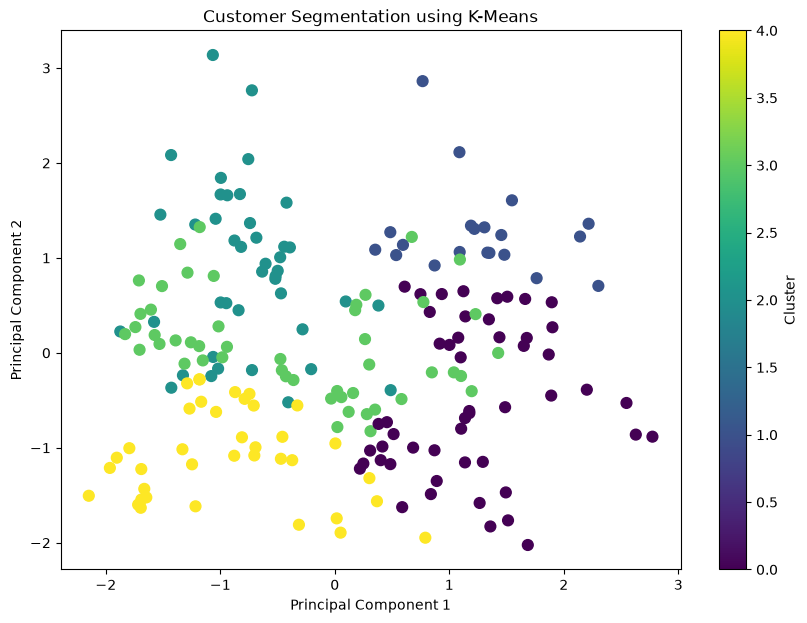

In [32]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_pca["PC1"],
    X_pca["PC2"],
    c=clusters,
    cmap="viridis",
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using K-Means")

plt.colorbar(label="Cluster")
plt.show()

### Interpretation

The scatter plot shows customers projected onto two principal components (PC1 and PC2).

Each point represents one customer, while different colors represent different clusters assigned by the K-Means algorithm.

Most clusters are clearly separated, indicating that customers with similar characteristics have been grouped together successfully.

A small overlap exists between some clusters, which is expected in real-world datasets because customer behaviour is not perfectly distinct.

### Business Insight

The visualization confirms that the K-Means algorithm successfully identified five distinct customer segments.

These customer groups can be targeted using different marketing strategies such as:

- Loyalty programs
- Premium memberships
- Discount campaigns
- Personalized product recommendations

C:\Users\anujb\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


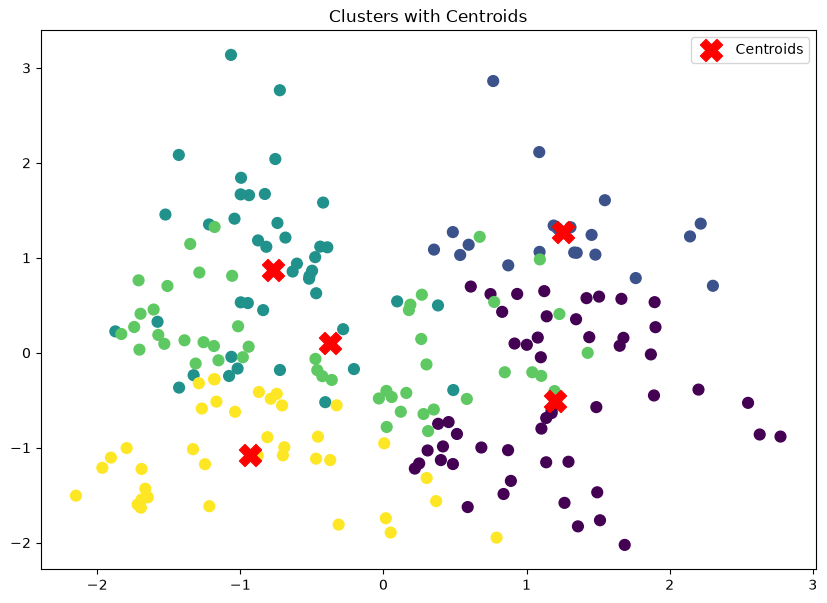

In [37]:
centers = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(10,7))

# Plot customers
plt.scatter(
    X_pca["PC1"],
    X_pca["PC2"],
    c=clusters,
    cmap="viridis",
    s=60
)
#plot centroid
plt.scatter( 
    centers[:,0],
    centers[:,1],
    c="red",
    marker="X",
    s=250,
    label="Centroids"
) 
plt.legend()
plt.title("Clusters with Centroids")
plt.show()

### Interpretation

The red **X** markers indicate the centroid of each cluster.

A centroid represents the average position of all customers belonging to that cluster.

Each customer is assigned to the nearest centroid based on Euclidean distance.

The centroids lie near the center of their respective customer groups, indicating that the K-Means algorithm successfully identified meaningful clusters.

### Business Insight

Each centroid represents the typical characteristics of customers within that segment.

Businesses can analyze these centroids to understand customer behaviour and develop targeted marketing strategies for each customer group.

In [38]:
cluster_details = data.groupby("Cluster").agg({
    "Age":"mean",
    "Annual Income (k$)":"mean",
    "Spending Score (1-100)":"mean"
})

cluster_details

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,56.470588,46.098039,39.313725
1,39.500000,85.150000,14.050000
2,28.690476,60.904762,70.238095
3,37.897959,82.122449,54.448980
4,27.315789,38.842105,56.210526


# Cluster Profiling

## Objective

After assigning customers to clusters, the average characteristics of each cluster are calculated.

This helps us understand the behavior of customers in each segment and generate meaningful business insights.

### Interpretation

The table summarizes the average characteristics of customers within each cluster.

Observations:

- **Cluster 0**
  - Average Age ≈ 56 years
  - Average Income ≈ 46k
  - Average Spending Score ≈ 39
  - Older customers with relatively low spending.

- **Cluster 1**
  - Average Age ≈ 40 years
  - Average Income ≈ 85k
  - Average Spending Score ≈ 14
  - High-income customers who spend very little.

- **Cluster 2**
  - Average Age ≈ 29 years
  - Average Income ≈ 61k
  - Average Spending Score ≈ 70
  - Young customers with high spending behaviour.

- **Cluster 3**
  - Average Age ≈ 38 years
  - Average Income ≈ 82k
  - Average Spending Score ≈ 54
  - High-income customers with moderate spending.

- **Cluster 4**
  - Average Age ≈ 27 years
  - Average Income ≈ 39k
  - Average Spending Score ≈ 56
  - Young customers with relatively low income but good spending behaviour.

## Business Recommendations

### Cluster 0
Offer loyalty programs and discounts to increase spending.

### Cluster 1
Provide premium products and personalized offers to encourage purchases.

### Cluster 2
Target with VIP memberships, exclusive offers, and premium services.

### Cluster 3
Maintain customer engagement using seasonal promotions and personalized recommendations.

### Cluster 4
Offer affordable products and student discounts to retain these young customers.

# Project Conclusion

## Conclusion

This project successfully applied **K-Means Clustering**, an unsupervised machine learning algorithm, to segment mall customers based on their demographic and spending characteristics.

The project followed a complete machine learning workflow, including:

- Data Loading
- Data Understanding
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Label Encoding
- Feature Standardization
- Principal Component Analysis (PCA)
- Elbow Method for selecting the optimal number of clusters
- K-Means Model Training
- Cluster Visualization
- Cluster Profiling
- Business Recommendations

The Elbow Method indicated that **5 clusters** provided the optimal balance between model simplicity and clustering performance.

Cluster profiling revealed distinct customer groups with different characteristics, such as:

- Young customers with high spending behaviour.
- High-income customers with low spending behaviour.
- Older customers with moderate spending behaviour.
- Young customers with lower income but relatively higher spending.

These customer segments can help businesses develop targeted marketing strategies, improve customer satisfaction, increase customer retention, and maximize revenue through personalized offers.

Overall, this project demonstrates how unsupervised machine learning can uncover hidden patterns in customer data and support data-driven business decision-making.

# Skills Demonstrated

During this project, the following skills were applied:

- Python Programming
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Label Encoding
- StandardScaler
- Principal Component Analysis (PCA)
- K-Means Clustering
- Elbow Method
- Data Visualization
- Customer Segmentation
- Business Insight Generation

# Key Learnings

Through this project, I learned:

- How to preprocess real-world datasets.
- Why feature scaling is important for distance-based algorithms.
- How PCA reduces dimensionality while preserving information.
- How the Elbow Method helps determine the optimal number of clusters.
- How to interpret customer segments and convert them into actionable business insights.